# Data Loading

This notebook shows how to load data from single or multiple sources.

In [1]:
# Ensure crest is in the system path to allow importing from the package. 
%cd -q ..

## Set up a synthetic dataset
First, we create a simple 1-dimensional problem setting which consists of three xarray Datasets. 

The configuration dict `config` contains the data definitions, which looks like this:
```python
# Data definitions
'data_kwargs' : [
    {'dimensions' : {'x' :  9}, 'chunks': {'x': 3}}, # 1st data object 
    {'dimensions' : {'x' : 17}, 'chunks': {'x': 6}}, # 2nd data object  
    {'dimensions' : {'x' :  6}, 'chunks': {'x': 2}}, # 3rd data object 
],
```

where:
 - `dimensions` labels the coordinates to be used, as well as their length
 - `chunks` determines how many elements should be in each dask chunk (e.g. `{'x': 3}` indicates there should be 3 elements along the 'x' dimension in each dask chunk).

The configuration also contains the window depths:
```python
# Window depths
'depth' : [
    {'x': 1}, # 1st data object
    {'x': 2}, # 2nd data object
    {'x': 0}, # 3rd data object
],
```

where `{'x': N}` indicates there should be `N` elements on either side of the center value along the 'x' dimension when a window is created. For example, using data equal to `[1, 2, 3, 4, 5]`, a depth of 1 and the window centered around `2` would look like `[1, 2, 3]`. 

Note that window depth can also use the format `(before, after)` to allow for asymmetric windows. For example, with the same data and window center, a depth of (0, 1) would result in `[2, 3]`.

In [2]:
from tests.data.loading.Dataset_config import configs
from crest.utils.synthetic_data import synthetic_data

config = configs['1d'].copy()
depth  = config.pop('depth')
data   = synthetic_data(**config)  

print('Window depths:', depth)

<xarray.Dataset>
Dimensions:  (x: 9)
Coordinates:
  * x        (x) float32 0.0 20.0 40.0 60.0 80.0 100.0 120.0 140.0 160.0
Data variables:
    var_0    (x) float32 dask.array<chunksize=(3,), meta=np.ndarray>

<xarray.Dataset>
Dimensions:  (x: 17)
Coordinates:
  * x        (x) float32 0.0 10.0 20.0 30.0 40.0 ... 130.0 140.0 150.0 160.0
Data variables:
    var_0    (x) float32 dask.array<chunksize=(6,), meta=np.ndarray>

<xarray.Dataset>
Dimensions:  (x: 6)
Coordinates:
  * x        (x) float32 0.0 30.0 60.0 90.0 120.0 150.0
Data variables:
    var_0    (x) float32 dask.array<chunksize=(2,), meta=np.ndarray>

Window depths: [{'x': 1}, {'x': 2}, {'x': 0}]


## Create the Dataset object
The top-level interface for loading data is the `crest.src.data.Dataset` class, which is created by passing in a number of `crest.src.data.Datafile` objects. 

`crest.src.data.Datafile` is simply a class which encapsulates the idea of loading from a single source of data. Ultimately, it's just a wrapper around xarray which provides a few additional helper functions and metadata. 

A number of options are available to customize how a data source is handled. The main parameters are:
- <u>**location**</u> : `Path | str | FSMap | xarray.Dataset`
    - _pathlib.Path_ or string defining a disk location of a zarr database
    - _fsspec.mapping.FSMap_ defining a remote location of a zarr database (e.g. AWS S3 bucket)
    - _xarray.Dataset_ object for data which has already been loaded
<br><br>

- <u>**features**</u> : `list[str]`
    - list of strings indicating the features to load
    - by default, all features are used
<br><br>

- <u>**extent**</u> : `dict[str, Collection[Number]]`
    - dictionary mapping {dimension: [lower bound, upper bound]}
    - e.g. {'latitude': [10, 20]} would only load data between 10 and 20 degrees latitude
    - by default, the full extent is used
<br><br>

- <u>**window_depth**</u> : `dict[str, Int | Collection[Int]]`
   - dictionary mapping {dimension: depth}
   - e.g. {'latitude': 2} would create windows with 2 elements on either side of the center
   - depth can also use the format (before, after) to create asymmetric windows
   - by default, a window depth of 0 is used (so only the center value is returned)
<br><br>   
  
- <u>**valid_percent**</u> : `dict[str | tuple[str], Number]`
    - dictionary mapping {dimension: percent}
    - e.g. {'latitude': 0.8} means for a window to be valid, >=80% of its latitude dimension must be valid
    - dimension can also be a tuple, giving the percent which must be valid along the _combination_ of dimensions
    - e.g. {('latitude', 'longitude'): 0.8} means >=80% of the lat lon grid for a window must be valid
    - by default, all elements must be valid (not NaN, etc.)
<br><br>

Further details can be found in the `crest.src.data.Datafile` docstring. 

#### For this simple example, all we need to pass in are the window depths which were defined in the configuration:

In [3]:
from crest.data.loading.Datafile import Datafile
from crest.data.loading.Dataset import Dataset

# Define the Datafiles - one per xarray.Dataset - then wrap in a crest Dataset
datafiles = [Datafile(d, window_depth=size) for d, size in zip(data, depth)]
dataset   = Dataset(datafiles)
dataset

Dataset[Datafile[0:Dataset_86b1], Datafile[1:Dataset_b65b], Datafile[2:Dataset_d83a]]

## Generate all samples
To actually load windows from the data, we simply use the function `Dataset.generate_samples`. This function has two optional parameters:
- <u>**numblocks**</u> : `list[int] | None`
    - a list of integers, one per dimension, which defines the number of blocks each dimension should be split into
    - blocks subset the data and are processed in parallel, leading to faster runtime and a smaller memory footprint
    - _however, too many blocks can cause slower overall runtime due to overhead_
    - number of blocks **must** result in the same number of elements per block, minus the last
    - e.g. [1,2,3,4] cannot be divided into 3 blocks because that would lead to [[1,2], [3], [4]]
    - by default numblocks is determined automatically via the data chunking, but this can be suboptimal
<br><br>

- <u>**verbose**</u> : `bool`
    - setting verbose to False will disable showing any logs when generating samples (True by default)

In [4]:
samples = dataset.generate_samples()
samples


____________________________________________________________

Current data:
------------------------------------------------------------

<xarray.DataArray (x: 9, features: 1)>
dask.array<transpose, shape=(9, 1), dtype=float32, chunksize=(3, 1), chunktype=numpy.ndarray>
Coordinates:
  * x         (x) float32 0.0 20.0 40.0 60.0 80.0 100.0 120.0 140.0 160.0
  * features  (features) object 'var_0'
Attributes:
    Datafile.config:       {'location': '<xarray.Dataset>\nDimensions:  (x: 9...
    Datafile.config_hash:  86b1fccda8db67dca674b9a57f7933e14c631a29530632efb3...

<xarray.DataArray (x: 17, features: 1)>
dask.array<transpose, shape=(17, 1), dtype=float32, chunksize=(6, 1), chunktype=numpy.ndarray>
Coordinates:
  * x         (x) float32 0.0 10.0 20.0 30.0 40.0 ... 130.0 140.0 150.0 160.0
  * features  (features) object 'var_0'
Attributes:
    Datafile.config:       {'location': '<xarray.Dataset>\nDimensions:  (x: 1...
    Datafile.config_hash:  b65b4efd3e0637d203e88288d65874e93972cb82


Finding all valid samples...


[                                        ] | 0% Completed | 220.73 us

[########################################] | 100% Completed | 106.51 ms


Found 15 samples


dask.array<values, shape=(15,), dtype=[('Data_0', [('values', '<f4', (1, 3)), ('coords', [('features', '<f4', (1,)), ('x', '<f4', (3,))])]), ('Data_1', [('values', '<f4', (1, 5)), ('coords', [('features', '<f4', (1,)), ('x', '<f4', (5,))])]), ('Data_2', [('values', '<f4', (1, 1)), ('coords', [('features', '<f4', (1,)), ('x', '<f4', (1,))])])], chunksize=(15,), chunktype=numpy.ndarray>

## Examine a Sample
The object returned from `generate_samples` is a lazy dask array which contains all Samples which were found. This can be used just like a normal list, with the exception of needing to call `.compute()` to access the actual elements.

A `crest.src.data.Sample` object contains a list of `xarray.Dataset` objects, one per Datafile. Together, they represent the same coordinate location found between the Datafiles, and the respective data contained for each.

#### Let's look at the first sample:

In [5]:
sample = samples[0].compute()

# One data window per Datafile inside a sample
assert(len(sample) == len(dataset))

for data in sample: print(data, '\n')

<xarray.Dataset>
Dimensions:  (x: 3)
Coordinates:
  * x        (x) float32 0.0 20.0 40.0
Data variables:
    var_0    (x) float32 0.0 1.0 2.0
Attributes:
    resolution:  {'x': 20.0} 

<xarray.Dataset>
Dimensions:  (x: 5)
Coordinates:
  * x        (x) float32 0.0 10.0 20.0 30.0 40.0
Data variables:
    var_0    (x) float32 0.0 1.0 2.0 3.0 4.0
Attributes:
    resolution:  {'x': 10.0} 

<xarray.Dataset>
Dimensions:  (x: 1)
Coordinates:
  * x        (x) float32 30.0
Data variables:
    var_0    (x) float32 1.0
Attributes:
    resolution:  {'x': 30.0} 



## Check data windows against full data

We can also look at the locations which data was pulled from for each of the Samples.

#### First, a quick refresh on what the original full data looked like:

In [6]:
full = dataset.x.values.astype(int)

# Reorder the data by size
order, full = zip(*sorted(enumerate(full), key=lambda f: len(f[1])))

print('Full data:')
for data in full:
    print(data)

Full data:
[  0  30  60  90 120 150]
[  0  20  40  60  80 100 120 140 160]
[  0  10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160]


#### Now let's iterate through the samples and highlight where each window appears in its respective Datafile.
Note: you can slow down the iteration by changing the sleep time on the last line of the cell.

In [7]:
from IPython.display import HTML, display, clear_output
import time

def highlight(data, window, index):
    """ Display the data elements and highlight the window """
    color = ['red', 'green', 'blue'][index]
    style = '{}; font-weight: bold; text-decoration: {}'
    
    default = style.format('black', 'none')
    inside  = style.format(color, 'none')
    center  = style.format(color, 'underline')
    
    is_mid = lambda i: list(window).index(i) == (len(window) // 2)
    styles = [(center if is_mid(i) else inside) if i in window else default for i in data]
    width  = 600 * max(data) / max(map(max, full))

    ele_style = 'color: {}; font-family: monospace; width:20px;'
    ele_html  = f'<span style="{ele_style}">{{}}</span>'
    tbl_style = f'display: flex; width: {width}px; justify-content: space-between; line-height:5px;'
    full_html = ''.join(map(ele_html.format, styles, data))
    display( HTML(f'<div style="{tbl_style}">{full_html}</div>') )

    
# Iterate over the samples, showing the location in the original data
for i, sample in enumerate(samples.compute(), 1):
    window = [sample[o].x.values.astype(int) for o in order]
    clear_output(True)
    
    print(f'Sample {i}/{len(samples)}:')
    for data in window:
        print(data)
    print()
    
    list(map(highlight, full, window, range(len(full))))
    time.sleep(0.5)

Sample 15/15:
[150]
[120 140 160]
[120 130 140 150 160]



#### That's it!

Samples can be iterated over and used in whatever ways make sense. What follows next is a brief overview of the internal logic of the process, and then an example of the loader being used on a much larger set of data. 

### Internal operation
<br>
<div>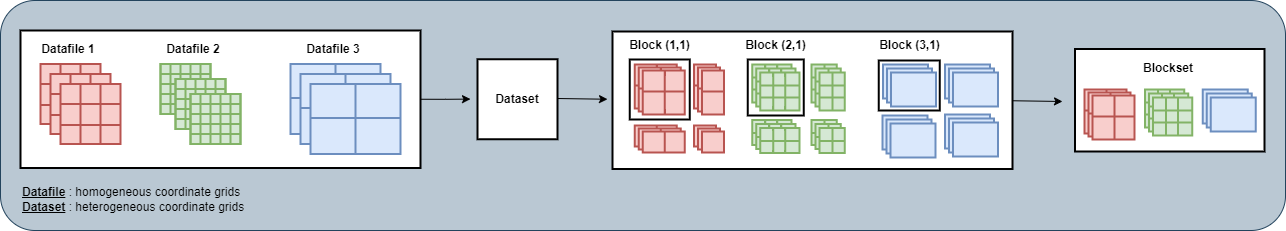</div>
<br>
The image above shows the broad outline of the process:

1. Datafiles are created, each containing data from a single source (i.e. a homogeneous coordinate grid) 
2. Dataset is created, which just wraps the Datafiles into a single object to operate on
3. Datafiles are divided into Blocks (with any necessary element overlaps at the edges)
4. One Block from each Datafile is taken to combine into a Blockset
5. Valid windows are found and matched between Blocks, and returned as the Samples (not shown)


#### Crest Classes:

<u>**Datafile**</u>  : `crest.src.data.loading.Datafile`<br>
<u>**Dataset**</u>   : `crest.src.data.loading.Dataset`<br>
<u>**Block**</u>     : `crest.src.data.loading.Block`<br>
<u>**Blockset**</u>  : `crest.src.data.loading.Blockset`<br>
<u>**Sample**</u>    : `crest.src.data.loading.Sample`<br>
    
<br>

Going into slightly more detail, you might have noticed when calling `generate_samples` that there are two high-level steps which happen when it's called:

- **Preparing data** : performs adjustments to get the data in a format which can be parallelized
    1. Create virtual dimensions, which are any dimensions in some Datafiles but not others
    2. Calculate the overlaps, which are the number of elements required to be shared along Block edges
    3. Update dask chunks to get the target number of Blocks and apply the calculated overlaps
    4. Create Blocksets that have one Block from each Datafile (e.g. 3 Datafiles, 5 Blocks each => 5 Blocksets, 3 Blocks each)
<br><br>

- **Finding all valid samples** : operates on each Blockset in parallel to find the valid sample windows within that set
    1. Find valid windows for each Block in the Blockset
    2. Match up valid windows between Blocks, where matched windows are within a certain distance of one another
    3. Create a lazy dask array containing the indices of matched windows
    4. Combine arrays from all Blocksets into the final array containing all samples
<br><br>

### Stress test

Now let's apply the loader to a much larger set of data. **Note that this will be using ~12GB of RAM by the end.** 

In [8]:
# Generate synthetic data:
#   First set shaped [10, 1000, 1000] w/ window depth [2, 5, 5]
#   Second set shaped [50, 500, 500] w/ window depth [2, 3, 3]
#   Third set shaped [300, 50, 50] w/ window depth [3, 3, 3]
config = configs['extra_large'].copy()
depth  = config.pop('depth')
data   = synthetic_data(verbose=False, **config)

# At least 80% of the combined (latitude, longitude) window must be valid
valid = {('latitude', 'longitude'): 0.8} 

datafiles = [Datafile(d, window_depth=size, valid_percent=valid) for d, size in zip(data, depth)]
dataset   = Dataset(datafiles)
dataset

Dataset[Datafile[0:Dataset_c9c6], Datafile[1:Dataset_7897], Datafile[2:Dataset_a960]]

#### The next cell should run in about 40 to 50 seconds, and find around 800 million samples.

In [9]:
# Split the first two dimensions into 10 blocks each (100 total)
# Note that Dataset will attempt to automatically rechunk and block the data
#  when necessary, but you can also set blocks manually as shown here
samples = dataset.generate_samples()
samples


____________________________________________________________

Current data:
------------------------------------------------------------

<xarray.DataArray (latitude: 1000, longitude: 1000, time: 10, features: 1)>
dask.array<transpose, shape=(1000, 1000, 10, 1), dtype=float32, chunksize=(1000, 1000, 10, 1), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) float32 0.0 3.3 6.6 9.9 13.2 16.5 19.8 23.1 26.4 29.7
  * latitude   (latitude) float32 0.0 10.0 20.0 ... 9.97e+03 9.98e+03 9.99e+03
  * longitude  (longitude) float32 0.0 10.0 20.0 ... 9.97e+03 9.98e+03 9.99e+03
  * features   (features) object 'var_0'
Attributes:
    Datafile.config:       {'location': '<xarray.Dataset>\nDimensions:    (ti...
    Datafile.config_hash:  c9c6858d128583248a8c23c86e83968b31b4846ade227ad2c6...

<xarray.DataArray (latitude: 500, longitude: 500, time: 50, features: 1)>
dask.array<transpose, shape=(500, 500, 50, 1), dtype=float32, chunksize=(500, 500, 50, 1), chunktype=numpy.ndarray>
Coordinates


Finding all valid samples...


[                                        ] | 0% Completed | 173.13 us

[###############                         ] | 38% Completed | 113.15 ms

[##################                      ] | 46% Completed | 235.00 ms

...

[######################################  ] | 96% Completed | 285.50 s

[######################################  ] | 96% Completed | 285.60 s

[########################################] | 100% Completed | 285.73 s


Found 595,177,858 samples


dask.array<concatenate, shape=(595177858,), dtype=[('Data_0', [('values', '<f4', (1, 2, 5, 5)), ('coords', [('features', '<f4', (1,)), ('time', '<f4', (2,)), ('latitude', '<f4', (5,)), ('longitude', '<f4', (5,))])]), ('Data_1', [('values', '<f4', (1, 2, 3, 3)), ('coords', [('features', '<f4', (1,)), ('time', '<f4', (2,)), ('latitude', '<f4', (3,)), ('longitude', '<f4', (3,))])]), ('Data_2', [('values', '<f4', (1, 3, 3, 3)), ('coords', [('features', '<f4', (1,)), ('time', '<f4', (3,)), ('latitude', '<f4', (3,)), ('longitude', '<f4', (3,))])])], chunksize=(1968504,), chunktype=numpy.ndarray>

### Timing checks
Check how quickly samples can be accessed and iterated.

In [10]:
from random import randint

i_vals = []
access = lambda i=0, n=1: (samples[i:i+n].compute(), i_vals.append(i))
total  = len(samples)

print('Sample access times:')

print('       First: ', end='')
%timeit -r 3 access(0)
print('        Last: ', end='')
%timeit -r 3 access(total)
print('      Random: ', end='')
%timeit -r 3 access(randint(0, total))

# Ensure unique random value used per timing run
assert(len(set(i_vals)) > 3), i_vals
i_vals = []

print('   First 10k: ', end='')
%timeit -r 3 access(n=1e4)
print('  First 100k: ', end='')
%timeit -r 3 access(n=1e5)
print(' Random 100k: ', end='')
%timeit -r 3 access(randint(0, total-1e5), 1e5)

# Ensure unique random value used per timing run
assert(len(set(i_vals)) > 2), i_vals

Sample access times:
       First: 

39.2 s ± 431 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)
        Last: 

1min 17s ± 195 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)
      Random: 

#### Should be able to iterate at ~ 35k Samples / second:

In [11]:
from tqdm import tqdm

with tqdm(total=len(samples), unit=' Samples', unit_scale=True, ncols=80, smoothing=0) as pbar:
    for block in samples.blocks:
        pbar.update( len(block.compute()) )
        if pbar.n > 1e6: break

  0%|                              | 1.00M/843M [00:15<3:42:02, 63.2k Samples/s]


## Batching

In machine learning applications, we need to divide the training data into smaller chunks of data to feed into the model. For instance, a dataset that has 10,000 samples might be divided into batches of 100 samples, leading to 100 batches per training epoch.

To do this with the data loader, we use the `crest.src.data.Batcher` class. By passing in a Dataset object, we can start creating batches of data immediately rather than loading the entire dataset at once. Similarly, because Dataset uses dask as the backend framework, we can pull different parts of the data to create multiple batches in parallel. 

The Batcher takes various parameters, a few of which are listed below:

- <u>**dataset**</u> : `crest.src.data.loading.Dataset`
    - Crest Dataset object
    
- <u>**batch_size**</u> : `int`
    - Number of samples that each batch should contain
    
- <u>**shuffle**</u> : `bool`
    - Whether samples should be shuffled to generate batches, or returned in their original order  
    


The Batcher can create batches without loading the entire dataset in memory, which makes the overall memory footprint very small. Because it generates batches in parallel, it also can iterate through them very quickly (albeit dependent on the chunksize of the data).

#### This will start out slow, but will gradually increase in speed to ~100 batches / second (i.e. ~14k samples / second):

In [12]:
from crest.data.Batcher import Batcher
with Batcher(dataset, batch_size=128, shuffle=True) as batches:

    # batches itself can be iterated over, but we can use .generator(show_timing=True) to measure performance
    for i, batch in enumerate( batches.generator(show_timing=True) ):

        # All but potentially the last batch will be the requested batch_size
        # The last batch will contain whatever leftover samples there are, when
        #   the data is not evenly divisible by the batch_size
        assert(len(batch) == 128)

        if i > 5000: break

Unable to join threads to shut down before fork(). This can break multithreading in child processes.

Unable to join threads to shut down before fork(). This can break multithreading in child processes.



0.00 Batches [00:00, ? Batches/s]

0.00 Samples [00:00, ? Samples/s]

Time to first batch: 4.7 seconds



In [13]:
batch[:3]

array([<crest.data.loading.Sample.Sample object at 0x1683a3640>,
      dtype=object)

In [14]:
# The batcher will return an array of `batch_size` Samples for each batch we request.
len(batch)

128